Load required libraries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
from scipy.sparse import lil_matrix,csr_matrix
import scipy.io
%config InlineBackend.figure_format='retina'

Function to split dataset into training and test data with fixed number of training samples for each label

In [3]:
def fixed_split(X, y, train_samples_per_class):
    
    X_train, X_test, y_train, y_test , indices_train, indices_test = [], [], [], [], [], []
    
    unique_labels = np.unique(y)
    
    for label in range(1,np.max(unique_labels)+1):
        indices = np.where(y == label)[0]  # Get all indices for the current label
        
        n_train = train_samples_per_class
        if len(indices)/2 <= train_samples_per_class:
            n_train = int(np.floor(len(indices)/2))
        
        # Shuffle indices
        np.random.shuffle(indices)

        # Split into train and test
        train_indices = indices[:n_train]
        test_indices = indices[n_train:]

        # Append to train/test lists
        X_train.append(X[train_indices,:])
        X_test.append(X[test_indices,:])
        y_train.append(y[train_indices])
        y_test.append(y[test_indices])
        indices_train.append(train_indices)
        indices_test.append(test_indices)

    # Stack results
    X_train, X_test = np.vstack(X_train), np.vstack(X_test)
    y_train, y_test = np.hstack(y_train), np.hstack(y_test)
    indices_train, indices_test = np.hstack(indices_train), np.hstack(indices_test)
    
    return X_train, X_test, y_train, y_test, indices_train, indices_test

Function to perform PCA

In [4]:
def pca(X, nComponents, center = True):
    '''
        The data matrix X consists of sample rows and feature columns
    '''
    
    import numpy as np
    
    if center:
        mean_sample = np.mean(X, axis=0, keepdims=True)
        
        X_centered = X - mean_sample
    
        U, S, VT = np.linalg.svd(X_centered, full_matrices=False)
    
        components = VT[:nComponents,:]

        projected_X = X @ components.T
        
        #projected_mean = mean_sample @ components.T
        #projected_X = projected_mean + X @ components.T
    
    else:
        U, S, VT = np.linalg.svd(X, full_matrices=False)

        components = VT[:nComponents,:]
        
        projected_X = X @ components.T
        
    return projected_X, components

Function to find distance between two pixel indices

In [5]:
def EuDist2(i1, i2, nX):
    
    x1 = i1 % nX
    y1 = i1 // nX
    
    x2 = i2 % nX
    y2 = i2 // nX
    
    return (x1-x2)**2 + (y1-y2)**2

Funtion to find distance matrix

In [6]:
def EuDist2Mat(indices, nX):
    d = np.zeros((len(indices),len(indices)))
    
    for i in range(len(indices)):
        d[i,:] = EuDist2(indices[i],indices,nX)
        
    return d

Function to reconstruct pixels in each superpixel

In [7]:
def reconstructSuperpixelDataMat(dataMat, indices, nX, k):
    
    distMat = EuDist2Mat(indices, nX)
    # Get the indices of the smallest k values in each row
    sorted_indices = np.argsort(distMat, axis=1)[:, :k+1]  # Indices of smallest k values for each row
    #sorted_indices = sorted_indices[:,1:]
    
    weightMat = lil_matrix(distMat.shape)
    
    # Populate only the smallest k values in the sparse matrix
    for i in range(distMat.shape[0]):
        
        temp = np.sum((dataMat[i,:] - dataMat[sorted_indices[i],:])**2,axis=1)
        
        t = 1/k*np.sum(temp)
        
        weightMat[i,sorted_indices[i]] = np.exp(-temp/(2*t))/np.sum(np.exp(-temp/(2*t)))

    # Convert to CSR format for efficient operations
    weightMat = weightMat.tocsr()   
    
    reconstructedDataMat = weightMat @ dataMat 
    
    return reconstructedDataMat
    

Function to construct superpixelwise data matrices from global data matrix 

In [8]:
def superpixelwiseDataMatFromGlobalDataMat(globalDataMat, segmentsVec):
    
    nPix = globalDataMat.shape[0]
    nBands = globalDataMat.shape[1]
    nSegments = segmentsVec.shape[0]
    
    superpixelwise_dataMat = []
    superpixelwise_indexVec = []

    
    for i in range(0,nSegments):
        segmentiMat =  np.empty((0, nBands))
        segmentiIndicesVec =  np.array([])
        superpixelwise_dataMat.append(segmentiMat)
        superpixelwise_indexVec.append(segmentiIndicesVec)
    
    for i in range(0,nPix):
        superpixelwise_dataMat[int(segmentsVec[i])] = np.vstack([superpixelwise_dataMat[segmentsVec[i]], globalDataMat[i,:]])
        superpixelwise_indexVec[int(segmentsVec[i])] = np.append(superpixelwise_indexVec[int(segmentsVec[i])], int(i))
        
    return superpixelwise_dataMat, superpixelwise_indexVec

Function to construct global data matrix from superpixelwise data matrices

In [9]:
# Reassemble 2D data array 
def globalDataMatFromSuperpixelwiseDataMat(superpixelwise_dataMat, superpixelwise_indexVec):

    nPix = sum(len(v) for v in superpixelwise_indexVec)
    nBands = superpixelwise_dataMat[0].shape[1]
    nSegments = len(superpixelwise_indexVec)
    
    globalDataMat = np.zeros((nPix,nBands))
    
    for i in range(0,nSegments):
        for j in range(0,len(superpixelwise_indexVec[i])):
            pixel_index = int(superpixelwise_indexVec[i][j])
            globalDataMat[pixel_index,:] = superpixelwise_dataMat[i][j,:]
            
    return globalDataMat      

Load Data

In [10]:
data3D = scipy.io.loadmat("Data\Indian_pines_corrected.mat")
labels = scipy.io.loadmat("Data\Indian_pines_gt.mat")

View Data

In [11]:
print(data3D.keys())
print(labels.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_corrected'])
dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_gt'])


In [12]:
data3Darr = data3D['indian_pines_corrected']

# Normalize 
data3Darr = data3Darr/np.max(data3Darr) #np.max(data3D_array, axis=(0,1), keepdims=True) # 
labelsMat = labels['indian_pines_gt']

print(data3Darr.shape)

print(labelsMat.shape)

nY = data3Darr.shape[0]
nX = data3Darr.shape[1]
nBands = data3Darr.shape[2]
nPix = nX*nY

min_label = np.min(labelsMat)
max_label = np.max(labelsMat)

(145, 145, 200)
(145, 145)


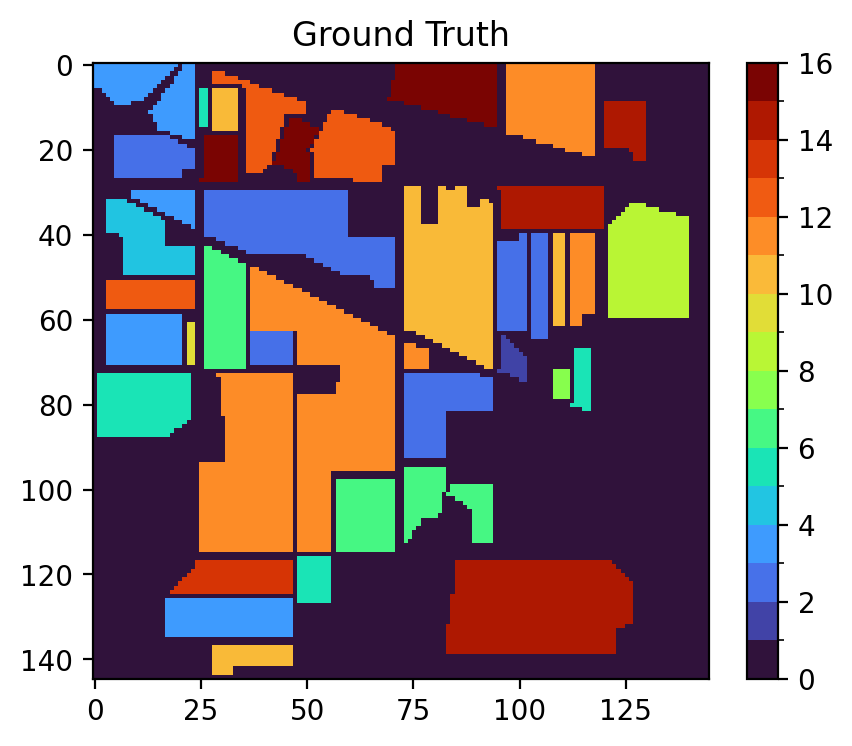

In [13]:
# Use Turbo colormap from Matplotlib
cmap = pl.cm.turbo

# Define discrete boundaries for the values (0 to 16)
bounds = np.arange(min_label, max_label+1, 1)  # Ensures correct mapping of colors
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(labelsMat, cmap=cmap,norm=norm)
pl.colorbar()
pl.title(r"Ground Truth")
pl.show()

In [14]:
# Get number of pixels (samples) with each label
unique_labels = np.arange(min_label,max_label+1,1)
label_count = np.zeros_like(unique_labels)

for i in range(0,len(label_count)):
    label_count[i] = (labelsMat == unique_labels[i]).sum()

label_count_df = pd.DataFrame({"Class Label":unique_labels, "Number of Samples":label_count})

print(label_count_df)

    Class Label  Number of Samples
0             0              10776
1             1                 46
2             2               1428
3             3                830
4             4                237
5             5                483
6             6                730
7             7                 28
8             8                478
9             9                 20
10           10                972
11           11               2455
12           12                593
13           13                205
14           14               1265
15           15                386
16           16                 93


SLIC Superpixelization

In [15]:
# Form data array of form (Rows -> samples (pixels), Columns -> features (bands))
# Note that in matlab, data array should be of form (Rows -> features (bands), Columns -> samples (pixels)) 

dataMat = data3Darr.reshape(nPix, nBands) #np.zeros((nPix, nBands)) #
    
labelsVec = labelsMat.reshape(nPix)
print(dataMat.shape)

# Get first principal component 

X_pca, components = pca(dataMat, 1)

(21025, 200)


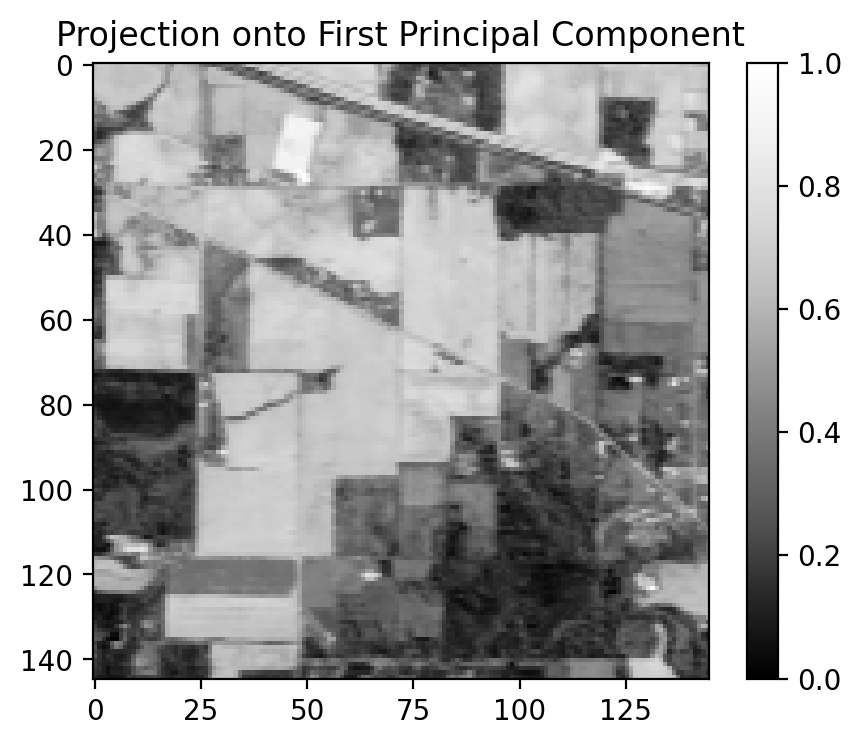

In [16]:
# Reshape into 2D image
img_pca = X_pca.reshape(nY,nX)

# Normalize to range [0,1] for imshow
img_pca = (img_pca - np.min(img_pca))/(np.max(img_pca)-np.min(img_pca))

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(img_pca, cmap='Greys_r')
pl.colorbar()
pl.title('Projection onto First Principal Component')
pl.show()

SLIC number of segments: 96


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.037975464883877076..1.0016150311814884].


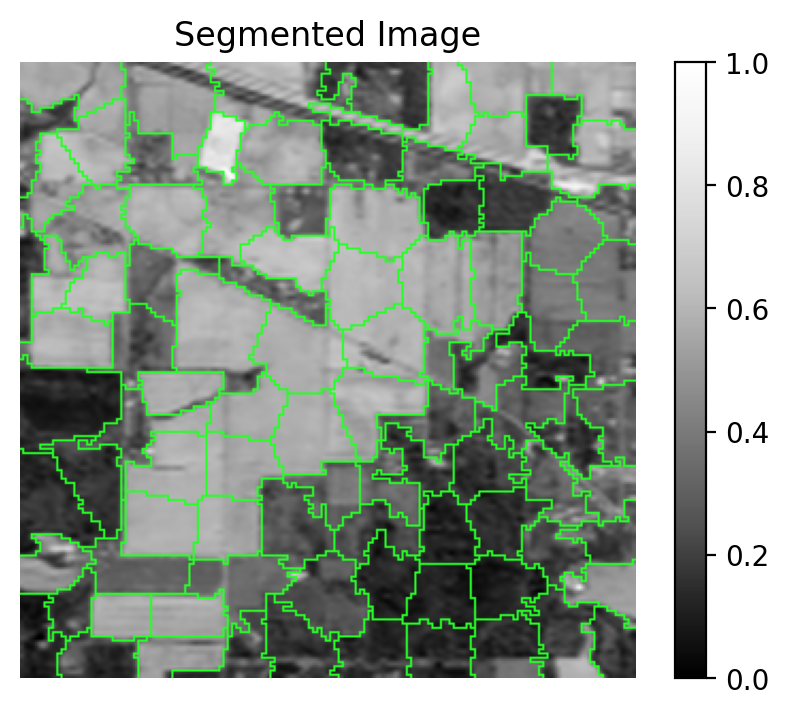

In [17]:
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
segments = slic(img_pca, channel_axis=None, n_segments=90, sigma=0.0, compactness=0.2,start_label=0)
nSegments = len(np.unique(segments))
print(f'SLIC number of segments: {nSegments}')

fig, axes = pl.subplots(figsize=(5,4))
pl.imshow(mark_boundaries(img_pca, segments,color=(0.15, 1.0, 0.15),mode='subpixel'),cmap='Greys_r')
pl.title(r"Segmented Image")
pl.axis('off')
#pl.savefig('SLIC.png',dpi=600)
pl.colorbar()
pl.show()

In [18]:
segmentsVec = segments.reshape(nPix)

superpixelwise_dataMat, superpixelwise_indexVec = superpixelwiseDataMatFromGlobalDataMat(dataMat, segmentsVec)

'''
superpixelwise_indexVec = []

for i in range(0,nSegments):
    segmentiMat =  np.empty((0, nBands))
    segmentiIndicesVec =  np.array([])
    superpixelwise_dataMat.append(segmentiMat)
    superpixelwise_indexVec.append(segmentiIndicesVec)
    
for i in range(0,nPix):
    superpixelwise_dataMat[int(segmentsVec[i])] = np.vstack([superpixelwise_dataMat[segmentsVec[i]], dataMat[i,:]])
    superpixelwise_indexVec[int(segmentsVec[i])] = np.append(superpixelwise_indexVec[int(segmentsVec[i])], int(i))
'''

'\nsuperpixelwise_indexVec = []\n\nfor i in range(0,nSegments):\n    segmentiMat =  np.empty((0, nBands))\n    segmentiIndicesVec =  np.array([])\n    superpixelwise_dataMat.append(segmentiMat)\n    superpixelwise_indexVec.append(segmentiIndicesVec)\n    \nfor i in range(0,nPix):\n    superpixelwise_dataMat[int(segmentsVec[i])] = np.vstack([superpixelwise_dataMat[segmentsVec[i]], dataMat[i,:]])\n    superpixelwise_indexVec[int(segmentsVec[i])] = np.append(superpixelwise_indexVec[int(segmentsVec[i])], int(i))\n'

Perform local superpixelwise reconstruction of each pixel

In [19]:
superpixelwise_reconstructedDataMat = []

k = 15

for i in range(nSegments):
    superpixelwise_reconstructedDataMat.append(reconstructSuperpixelDataMat(superpixelwise_dataMat[i],superpixelwise_indexVec[i],nX,k))

reconstructedDataMat = globalDataMatFromSuperpixelwiseDataMat(superpixelwise_reconstructedDataMat,superpixelwise_indexVec)

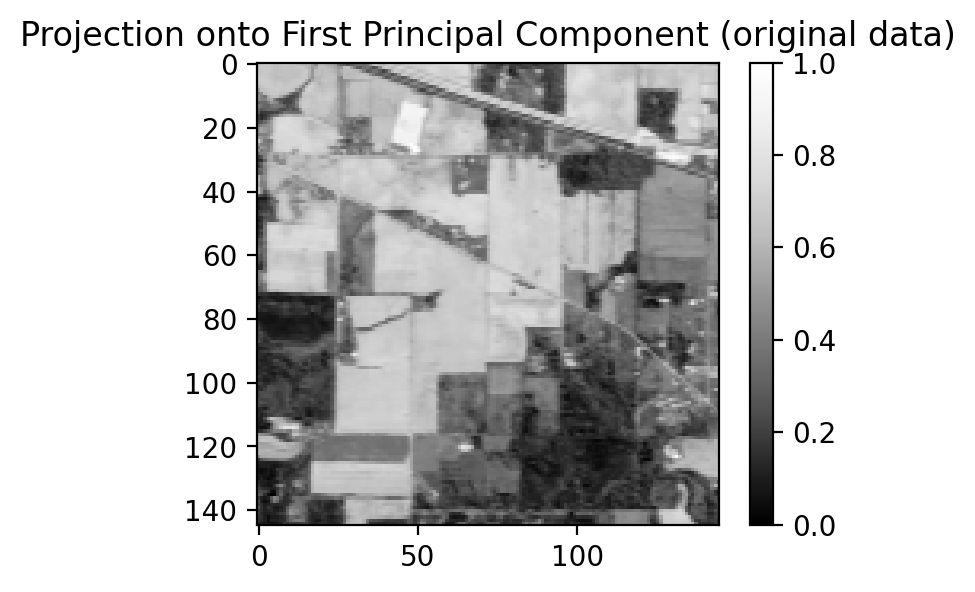

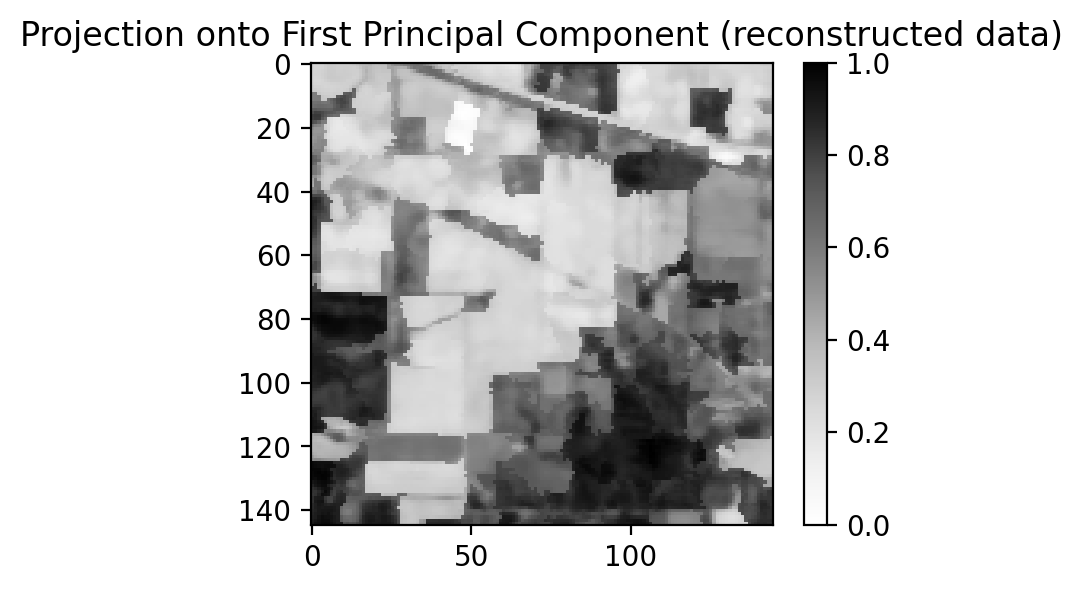

In [20]:
X2_pca, components = pca(reconstructedDataMat, 1)

# Reshape into 2D image
img2_pca = X2_pca.reshape(nY,nX)

# Normalize to range [0,1] for imshow
img2_pca = (img2_pca - np.min(img2_pca))/(np.max(img2_pca)-np.min(img2_pca))

fig, axes = pl.subplots(figsize=(4,3))
pl.imshow(img_pca, cmap='Greys_r')
pl.colorbar()
pl.title('Projection onto First Principal Component (original data)')
pl.show()

fig, axes = pl.subplots(figsize=(4,3))
pl.imshow(img2_pca, cmap='Greys')
pl.colorbar()
pl.title('Projection onto First Principal Component (reconstructed data)')
pl.show()

Perform Segmentation on Reconstructed data

Perform PCA on each superpixel

In [21]:
nComponents = 30

superpixelwise_reducedDataMat = []

for i in range(0,nSegments):
    
    segmenti_dataMatReduced, components = pca(superpixelwise_reconstructedDataMat[i], nComponents)
    superpixelwise_reducedDataMat.append(segmenti_dataMatReduced)
    
superpixelwiseReducedDataMat = globalDataMatFromSuperpixelwiseDataMat(superpixelwise_reducedDataMat, superpixelwise_indexVec)

Perform global PCA and concatenate

In [22]:
globalReducedMat, components = pca(reconstructedDataMat, nComponents)

intermediateDataMat = np.hstack((globalReducedMat, superpixelwiseReducedDataMat))

reducedDataMat, components = pca(intermediateDataMat, nComponents)

Perform SVM classification

In [23]:
# Import datasets, classifiers and performance metrics
from sklearn import metrics, svm

# Create indices for tracking
indices = np.arange(nPix)

# Split data into 30 training samples per label and remaining test samples
X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(reducedDataMat, labelsVec, 30)

# Convert 1D indices back to 2D coordinates
rows, cols = np.unravel_index(indices, img_pca.shape)
'''
# Plot the image
pl.imshow(img_pca, cmap="Greys_r")
pl.scatter(cols, rows, color='red', s=0.1)  # Highlight pixels in red
pl.title("Training Pixels")
pl.show()
'''


'\n# Plot the image\npl.imshow(img_pca, cmap="Greys_r")\npl.scatter(cols, rows, color=\'red\', s=0.1)  # Highlight pixels in red\npl.title("Training Pixels")\npl.show()\n'

In [24]:
# Create a classifier: a support vector classifier
clf = svm.SVC(kernel = 'rbf')

# Define parameter grid
param_grid = {'gamma': [0.01, 0.03, 0.07, 0.1, 0.3, 0.5, 0.7, 1, 3, 10, 30, 100], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 7e2, 1e3, 3e3, 1e4, 3e4, 1e5]}

from sklearn.model_selection import GridSearchCV

# Use GridSearchCV
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'C': 100.0, 'gamma': 0.7}
Best cross-validation score: 0.9542842215256009


In [25]:
gamma = grid_search.best_params_['gamma']
C = grid_search.best_params_['C']

clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)

clf.fit(X_train, y_train)

# Predict the value of the digit on the test subset
predicted = clf.predict(X_test)

# Generate classification report
report = metrics.classification_report(y_test, predicted, output_dict=True)

print(
    f"Classification report for classifier {svm}:\n"
    f"{metrics.classification_report(y_test, predicted)}\n"
)

# Extract overall accuracy
overall_accuracy = report["accuracy"]
print(f"Overall Accuracy: {overall_accuracy:.4f}")

Classification report for classifier <module 'sklearn.svm' from 'c:\\Users\\shubh\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\sklearn\\svm\\__init__.py'>:
              precision    recall  f1-score   support

           1       0.64      1.00      0.78        23
           2       0.94      0.84      0.89      1398
           3       0.91      0.98      0.94       800
           4       0.94      0.97      0.95       207
           5       1.00      0.93      0.96       453
           6       1.00      0.98      0.99       700
           7       0.54      1.00      0.70        14
           8       1.00      1.00      1.00       448
           9       1.00      1.00      1.00        10
          10       0.89      0.93      0.91       942
          11       0.87      0.95      0.91      2425
          12       0.96      0.92      0.94       563
          13       1.00      0.99      1.00       175
          14       1.00      0.87      0.93      1235
          15

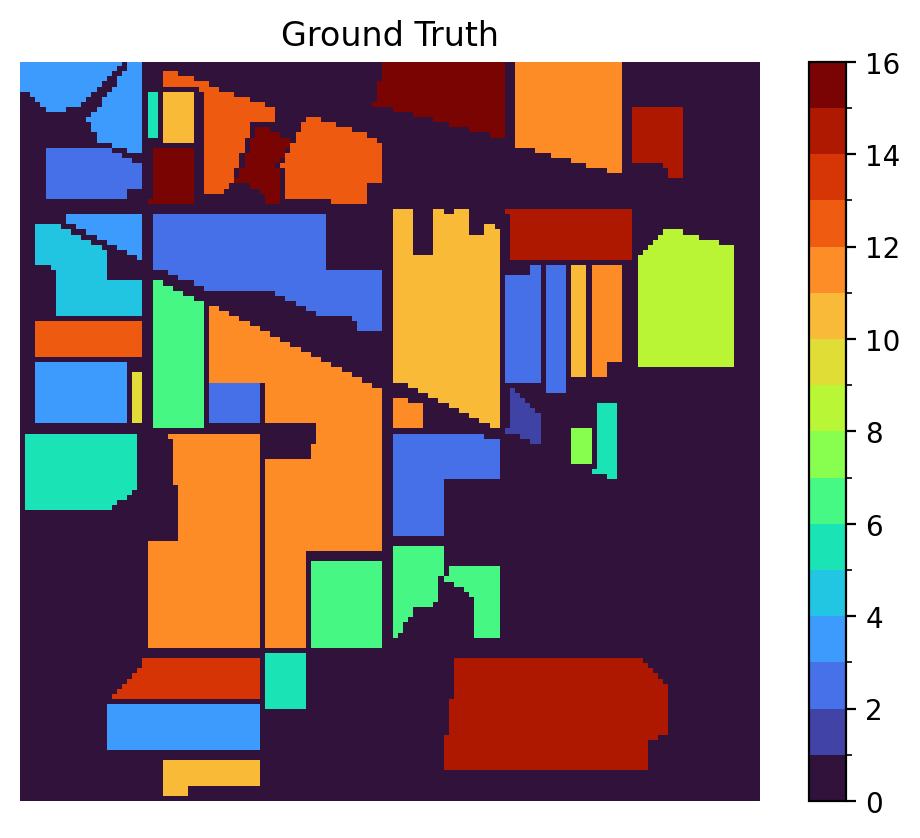

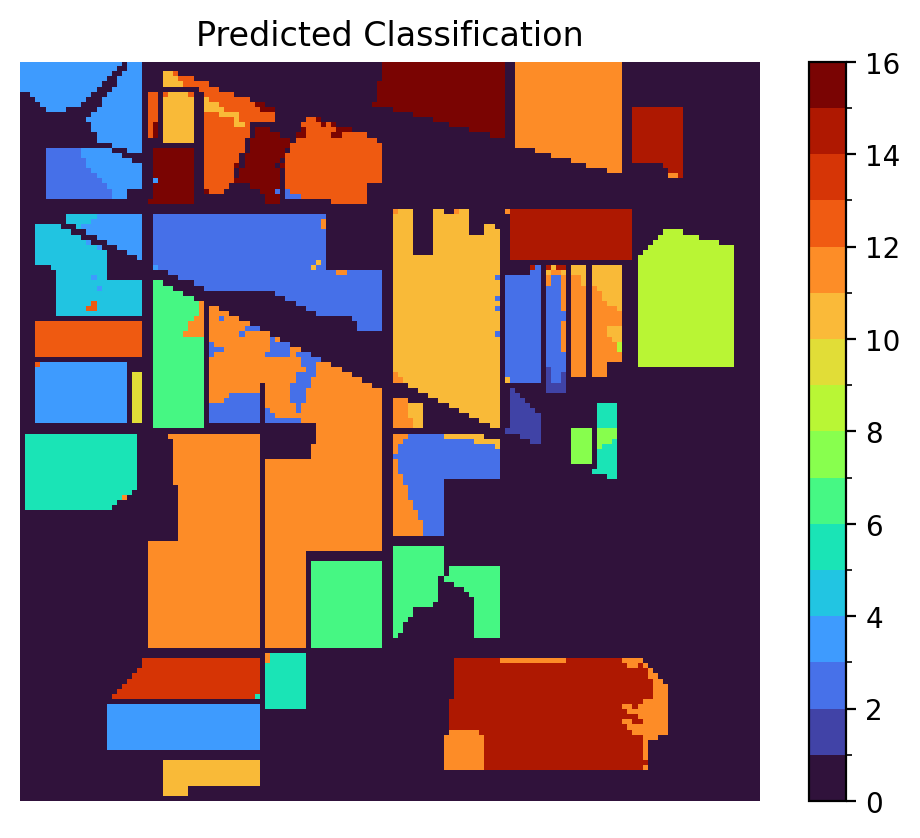

In [26]:
# Show predicted classification

labels_array_predicted = np.zeros(nPix)

labels_array_predicted[labelsVec != 0] = clf.predict(reducedDataMat[labelsVec != 0,:])

labels2D_array_predicted = labels_array_predicted.reshape(nY,nX)

pl.imshow(labelsMat, cmap=cmap,norm=norm)
pl.axis('off')
pl.colorbar()
pl.title(r"Ground Truth")
#pl.savefig('GroundTruth.png',dpi=600)
pl.show()
pl.imshow(labels2D_array_predicted, cmap=cmap,norm=norm)
pl.axis('off')
pl.colorbar()
pl.title(r"Predicted Classification")
pl.savefig('S3PCA.png',dpi=600)
pl.show()